---
title: US Market Trends Analysis
# subtitle: A Comprehensive Guide to Analyzing the S&P 500 Index Using Python
author: Samantha Pang
date: 2025-12-01
date-modified: last-modified 
format: 
    html: 
        toc: true
        code-fold: true
---


## Prerequisites!
Libraries needed for this exercise: yfinance, matplotlib, numpy, seaborn

## Objective
This project is to understand the leading indicators of the US stock market by analyzing the S&P500,  Dow Jones, and NASDAQ indices. We will explore historical data, visualize trends, and identify patterns that can help be well informed investors.

## leading indicators
### S&P 500 
The S&P 500, Standard & Poor's 500, is a stock market index that measures the stock performance of 500 large companies listed on stock exchanges in the US. It is one of the most commonly followed equity indices and is often considered a benchmark for the overall health of the US stock market.

### Dow Jones
The Dow Jones Industrial Average (DJIA) is a stock market index that measures the stock performance of 30 large, publicly-owned companies based in the US. It is one of the oldest and most widely recognized stock market indices in the world. 

### NASDAQ
The NASDAQ Composite is a stock market index that includes almost all stocks listed on the NASDAQ stock exchange. It is heavily weighted towards technology companies and is often used as a benchmark for the performance of the tech sector.

In [2]:
import yfinance as yf
import numpy as np

startdate = "1990-01-01"
enddate = "2025-12-31"
tickers = ["^GSPC", "^DJI", "^IXIC"]

# auto_adjust=True to get adjusted close prices (accounting for dividends and stock splits)
df = yf.download(
    tickers,
    start=startdate,
    end=enddate,
    auto_adjust=True
)["Close"]

sp500, dw30, nasdaq = df["^GSPC"], df["^DJI"], df["^IXIC"]

# today/yesterday price ratio / gross return
# log returns turn multiplicative processes into additive processes, making them easier to analyze statistically
def returns(prices):
    return np.log(prices/prices.shift(1)).dropna()

sp500ret, dw30ret, nasdaqret = returns(sp500), returns(dw30), returns(nasdaq)

[*********************100%***********************]  3 of 3 completed


S&P 500 's Total Return Over Past 30 Years:  2.9435
S&P 500 's Daily Volatility:  0.0114
Dow Jones 30 's Total Return Over Past 30 Years:  2.7262
Dow Jones 30 's Daily Volatility:  0.011
Nasdaq Composite 's Total Return Over Past 30 Years:  3.922
Nasdaq Composite 's Daily Volatility:  0.0146


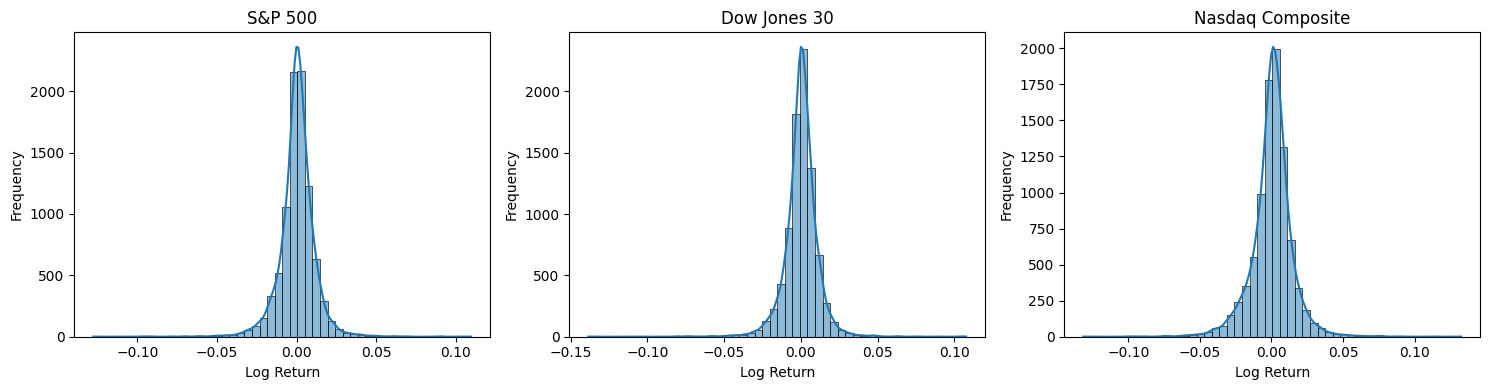

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
series_list = [sp500ret, dw30ret, nasdaqret]

for series, name, i in zip(series_list, ["S&P 500", "Dow Jones 30", "Nasdaq Composite"], range(3)):
    sns.histplot(series, kde=True, bins=50, ax=axes[i])
    axes[i].set_title(name)
    for ax in axes:
        ax.set_xlabel("Log Return")
        ax.set_ylabel("Frequency")
    print(name, "'s Total Return Over Past 30 Years: ",series.sum().round(4))
    print(name, "'s Daily Volatility: ", series.std().round(4)) 

plt.tight_layout()
plt.show()

Histogram shows a normal distribution of the logarithm return of all 3 of the indices over the last 30 year, which provides an insight into their performance and volatility. Majority of returns cluster around the mean indicates smaller data movement. probability of extreme returns (both positive and negative) is low, suggesting limited risk of significant losses or gains within this period. Overall, the histogram suggests that all 3 indices has relatively stable performance with moderate volatility over the year.

since the distribution appears normal, we can use mean and standard deviation to summarize the data.
~68% of daily returns fall within ±1 × std() of the mean
~95% within ±2 × std()
~99.7% within ±3 × std()

Annualized volatility (daily × √252)
Low: 5–10% → bonds, very stable ETFs
Medium: 15–20% → S&P 500 historically
High: 30–80% → tech stocks, small-cap, crypto